100%|██████████| 501/501 [00:01<00:00, 259.76it/s]


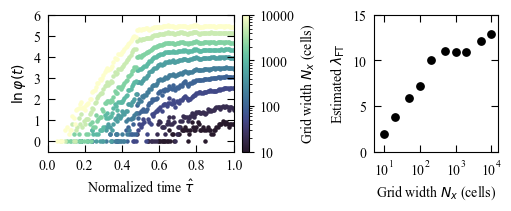

In [6]:
import numpy as np
import meanderpy as mp
import matplotlib.pyplot as plt
import cmocean
from matplotlib.colors import LogNorm
from matplotlib.cm import ScalarMappable
from matplotlib.ticker import LogFormatterMathtext

def plot_comparison(grid_logs, saved_ts, col_sizes, slopes, t0=50, t1=200):
    plt.rcParams["font.family"] = "Times New Roman"
    fig, (ax1, ax2) = plt.subplots(
        1, 2, figsize=(5, 2),
        gridspec_kw={'width_ratios': [1.5, 1], 'wspace': 0.05},
        constrained_layout=True
    )

    Nx_values = sorted(int(str(k).split('x')[-1]) for k in grid_logs.keys())
    cmap = cmocean.cm.deep_r
    norm = LogNorm(vmin=min(Nx_values), vmax=max(Nx_values))
    sm = ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])

    for label, ylog in grid_logs.items():
        Nx = int(str(label).split('x')[-1])
        color = cmap(norm(Nx))
        ylog = np.asarray(ylog)
        x = np.arange(len(ylog)) * saved_ts
        mask = (x >= t0) & (x <= t1) 
        x_norm = (x[mask] - t0) / (t1 - t0)
        ax1.scatter(x_norm, ylog[mask], color=color, s=5)

    ax1.set_xlabel(r'Normalized time $\hat{\tau}$')
    ax1.set_ylabel(r'$\ln \varphi(t)$')  
    ax1.set_xlim(0, 1)
    ax1.set_ylim(-0.5, 6)
    ax1.set_xticks([0, 0.2, 0.4, 0.6, 0.8,1.0])
    ax1.set_yticks([0, 1, 2, 3, 4, 5, 6])
    ax1.tick_params(axis='both', direction='in', top=True, right=True, pad=5, length=5)

    cbar_ticks = [t for t in [10, 100, 1000, 10000] if min(Nx_values) <= t <= max(Nx_values)]
    cbar = fig.colorbar(sm, ax=ax1, pad=0.0)
    cbar.set_label(r'Grid width $N_x$ (cells)')
    cbar.set_ticks(cbar_ticks)
    cbar.ax.set_yticklabels([f'{t}' for t in cbar_ticks])

    ax2.scatter(col_sizes, slopes, color='k', s=28, zorder=2)
    ax2.set_xscale('log')
    ax2.set_xlabel(r'Grid width $N_x$ (cells)')
    ax2.set_ylabel(r'Estimated $\lambda_{\mathrm{FT}}$')
    if cbar_ticks:
        ax2.set_xticks(cbar_ticks)
    ax2.get_xaxis().set_major_formatter(LogFormatterMathtext())
    ax2.set_xlim(min(col_sizes)*0.8, max(col_sizes)*1.25)
    ax2.set_xlim(5, 15000)
    ax2.set_ylim(0, 15)
    ax2.tick_params(axis='both', direction='in', top=True, right=True, pad=5, length=5)
    plt.show()

L = 10_000.0        
freq_multiplier = 30.0
amplitude = 3.0
nit = 501
saved_ts = 1
dY = 1e-10            # perturbation magnitude at center node
Nx_list = [10,20,50,100,200,500,1000,2000,5000,10000]
extent = (0, L, -2500, 2500)
n_seg_rasterize = 100 # polyline densification for rasterization
t0, t1 = 50, 200      # window for λ_FT estimation / plotting
n_fit = 50            # use first n_fit points in the masked window

def run_meander_simulation(freq_multiplier: float,
                           amplitude: float,
                           *,
                           n_perturb: int = 0,
                           perturb_magnitude: float = 0.0,
                           nit: int = 501,
                           saved_ts: int = 1):
    """Original structure: same numerics/physics, same initial sinusoid, optional center-node y-perturbation."""
    # physics / numerics
    W = 50.0;  D = 1.0
    depths  = D * np.ones(nit)
    pad, deltas = 0, 50.0
    Cfs     = 0.0065 * np.ones(nit)
    crdist  = 5 * W
    yr      = 365*24*60*60.0
    kl      = 500.0 / yr
    kv      = 1.0e-12
    dt      = 0.2 * 0.5 * yr  # = 0.1 yr, same as original
    dens    = 1000
    Sl      = 0.0
    t1p = t2p = t3p = 0
    aggr_factor = 0

    # initial planform
    x_initial = np.linspace(0.1, L, 1500)
    y_initial = (amplitude * 100.0) * np.sin(freq_multiplier * np.pi * x_initial / L)
    if n_perturb and perturb_magnitude:
        idx = len(x_initial) // 2
        y_initial[idx] += perturb_magnitude
    z_initial = np.zeros_like(x_initial)

    ch  = mp.Channel(x_initial, y_initial, z_initial, W, depths[0])
    chb = mp.ChannelBelt([ch], [], [0.0], [])
    chb.migrate(nit, saved_ts, deltas, pad, crdist,
                depths, Cfs, kl, kv, dt, dens,
                t1p, t2p, t3p, aggr_factor)
    return chb

def rasterize_channel(x, y, rows, cols, extent, n_seg=100):
    """Square-cell raster with polyline densification (identical logic)."""
    x_min, x_max, y_min, y_max = extent
    dx = (x_max - x_min) / cols
    dy = (y_max - y_min) / rows
    canvas = np.zeros((rows, cols), dtype=np.int8)
    if len(x) < 2: 
        return canvas
    for xa, ya, xb, yb in zip(x[:-1], y[:-1], x[1:], y[1:]):
        xs = np.linspace(xa, xb, n_seg)
        ys = np.linspace(ya, yb, n_seg)
        c = ((xs - x_min) / dx).astype(int)
        r = ((ys - y_min) / dy).astype(int)
        m = (0 <= c) & (c < cols) & (0 <= r) & (r < rows)
        canvas[r[m], c[m]] = 1
    return canvas

def compute_log_separation_series(chb_ref, chb_pert, Nx_list, extent, n_seg=100):
    """Build grid_logs: for each Nx, rows=Nx//2 to preserve square cells for the (2:1) aspect."""
    T = len(chb_ref.channels)
    grid_logs = {}
    for Nx in Nx_list:
        rows, cols = Nx // 2, Nx
        series = np.full(T, np.nan, dtype=float)
        for t in range(T):
            ch0 = chb_ref.channels[t]
            ch1 = chb_pert.channels[t]
            if ch0 is None or ch1 is None: 
                continue
            x0, y0 = getattr(ch0, 'x', None), getattr(ch0, 'y', None)
            x1, y1 = getattr(ch1, 'x', None), getattr(ch1, 'y', None)
            if any(v is None for v in (x0, y0, x1, y1)) or len(x0) < 2 or len(x1) < 2:
                continue
            g0 = rasterize_channel(x0, y0, rows, cols, extent, n_seg)
            g1 = rasterize_channel(x1, y1, rows, cols, extent, n_seg)
            # separation norm and safe log (exactly like original style)
            nrm = np.linalg.norm(g1 - g0)
            nrm = max(nrm, 1e-15)
            series[t] = np.log(nrm)
        grid_logs[f"{rows}x{cols}"] = series
    return grid_logs

def estimate_lambda_slopes(grid_logs, saved_ts=1, t0=50, t1=200, n_fit=50):
    """Mimic the original slope extraction:
       - window t∈[t0,t1]
       - keep y>=0
       - fit first n_fit points of y vs normalized time x̂=(t-t0)/(t1-t0)."""
    Nx_vals, lam = [], []
    for label in grid_logs:
        Nx = int(label.split('x')[-1])
        y = np.asarray(grid_logs[label])
        x = np.arange(len(y)) * saved_ts
        mask = (x >= t0) & (x <= t1) & np.isfinite(y) & (y >= 0)
        if mask.sum() < 5:
            Nx_vals.append(Nx); lam.append(np.nan); continue
        x_norm = (x[mask] - t0) / (t1 - t0)
        yw = y[mask]
        k = min(n_fit, len(x_norm))
        A = np.vstack([x_norm[:k], np.ones(k)]).T
        m, b = np.linalg.lstsq(A, yw[:k], rcond=None)[0]
        Nx_vals.append(Nx); lam.append(m)
    order = np.argsort(Nx_vals)
    return list(np.array(Nx_vals)[order]), list(np.array(lam)[order])

# ------------------------------- run everything -----------------------------
chb_ref  = run_meander_simulation(freq_multiplier, amplitude,
                                  n_perturb=0, perturb_magnitude=0.0,
                                  nit=nit, saved_ts=saved_ts)

chb_pert = run_meander_simulation(freq_multiplier, amplitude,
                                  n_perturb=1, perturb_magnitude=dY,
                                  nit=nit, saved_ts=saved_ts)

grid_logs = compute_log_separation_series(chb_ref, chb_pert, Nx_list, extent,
                                          n_seg=n_seg_rasterize)

col_sizes, slopes = estimate_lambda_slopes(grid_logs, saved_ts=saved_ts,
                                           t0=t0, t1=t1, n_fit=n_fit)

plot_comparison(grid_logs, saved_ts=saved_ts, col_sizes=col_sizes, slopes=slopes, t0=t0, t1=t1)